In [25]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import matplotlib.image as img
import tarfile
import re

IMAGE_TYPE_IDENTIFIER = '00280004'
# BASE_DIR = "/mnt/samsungUSB"
BASE_DIR = "."

# Organize data from .tar.gz batches

In [50]:
for f in os.listdir(BASE_DIR):
    if not f.startswith(".") and f.endswith(".tar.gz"):
        print(f"unpacking {f}...")
        with tarfile.open(os.path.join(BASE_DIR, f), 'r:gz') as tar:
            tar.extractall(path=BASE_DIR)

unpacking covid19_neg_subjects_partab.tar.gz...


/var/folders/t8/wvhcydtj09jffr6ydj99njk40000gn/T/ipykernel_57749/493309001.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=BASE_DIR)


unpacking covid19_posi_subjects_partaa.tar.gz...
unpacking covid19_posi_subjects_partab.tar.gz...
unpacking covid19_neg_subjects_partae.tar.gz...
unpacking covid19_posi_subjects_partac.tar.gz...
unpacking covid19_neg_subjects_partah.tar.gz...
unpacking covid19_posi_subjects_partad.tar.gz...
unpacking covid19_neg_subjects_partaf.tar.gz...


In [ ]:
def preprocess(start_dir, label):
    subjects = []
    images = []
    image_types = []
    sessions = []
    labels = []
    for root, _, files in os.walk(start_dir):
        with tqdm(total=len(files), desc=f"Processing {root}") as pbar:
            for f in files:
                pbar.update()
                if f.endswith(".png") and not f.startswith("."):
                    json_file = os.path.join(root, f.replace("png", "json"))
                    if not os.path.exists(json_file): continue
                    with Image.open(os.path.join(root, f)) as image:
                        resized_image = image.resize((224, 224))
                        resized_image.save(os.path.join("preprocessed", f))
                    subject = re.search(r"sub-S\d+", f).group()
                    subjects.append(subject)
                    session = re.search(r"ses-E\d+", f).group()
                    sessions.append(session)
                    image = os.path.join(root, f)
                    images.append(image)
                    with open(json_file) as file:
                        metadata = json.load(file)
                        image_type = metadata[IMAGE_TYPE_IDENTIFIER]['Value'][0]
                        image_types.append(image_type)
                    labels.append(label)
    return pd.DataFrame(data={'subject': subjects, 'image_path': images, 'image_type': image_types, 'session': sessions, 'label': labels})

In [51]:
os.makedirs("preprocessed", exist_ok=True)
df = pd.concat([preprocess(os.path.join(BASE_DIR, "covid19_posi"), True), preprocess(os.path.join(BASE_DIR, "covid19_neg"), False)])
print(df.shape)
df.head()

Processing...: 0it [00:00, ?it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 22/22 [00:00<00:00, 1139193.68it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 6/6 [00:00<00:00, 381300.36it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 4/4 [00:00<00:00, 15.24it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 4/4 [00:00<00:00, 14.84it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 2/2 [00:00<00:00, 12.89it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 3/3 [00:00<00:00, 49.75it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 2/2 [00:00<00:00, 11.79it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 3/3 [00:00<00:00, 23.14it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 2/2 [00:00<00:00, 25.01it/s]
Processing...: 0it [00:00, ?it/s]
Processing...: 100%|██████████| 2/2 [00:00<00:00, 11.93it/s]
Proce

KeyboardInterrupt: 

In [28]:
class ChestXRayDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        """
        Args:
            df:        DataFrame with 'image_path', 'label', 'image_type' columns
            base_dir:  Root directory where your images live (replaces the './')
            transform: torchvision transforms to apply
        """
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Build absolute path — replace leading './' with your base_dir
        rel_path = os.path.relpath(row['image_path'], './')
        img_path = os.path.join(self.base_dir, rel_path)

        # Load image as grayscale (X-rays are single channel)
        img = Image.open(img_path).convert('L')

        # Handle MONOCHROME1 (inverted) vs MONOCHROME2 (normal)
        # MONOCHROME1: 0=white, max=black — needs inversion
        if row['image_type'] == 'MONOCHROME1':
            img = Image.fromarray(np.invert(np.array(img)))

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(int(row['label']), dtype=torch.float32)
        return img, label

In [29]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                        # converts to [0, 1]
    transforms.Normalize(mean=[0.5], std=[0.5])   # grayscale: single channel
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [30]:
# df = pd.read_csv('data.csv')
subjects = df['subject'].unique()
np.random.seed(42)
np.random.shuffle(subjects)

split = int(0.8 * len(subjects))
train_subjects = subjects[:split]
val_subjects   = subjects[split:]

train_df = df[df['subject'].isin(train_subjects)]
val_df   = df[df['subject'].isin(val_subjects)]

print(f"Train: {len(train_df)} images ({train_df['label'].sum()} positive)")
print(f"Val:   {len(val_df)} images ({val_df['label'].sum()} positive)")

Train: 726 images (407 positive)
Val:   160 images (93 positive)


/tmp/ipykernel_213330/1918360245.py:4: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(subjects)


In [36]:
train_dataset = ChestXRayDataset(train_df, BASE_DIR, transform=train_transforms)
val_dataset   = ChestXRayDataset(val_df,   BASE_DIR, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [37]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Adapt first conv layer: 3-channel → 1-channel (grayscale)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Binary output
model.fc = nn.Linear(model.fc.in_features, 1)

In [40]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Convolutional Block 1
        # In Keras: Conv2D(32, (3,3)) -> input shape (224, 224, 1)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional Block 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected Layers
        # Flattened size calculation: 128 * 26 * 26 = 86,528
        self.fc1 = nn.Linear(128 * 26 * 26, 64)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        # Apply layers with ReLU activation
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        
        # Flatten: (Batch, Channels, H, W) -> (Batch, Channels * H * W)
        x = x.view(x.size(0), -1) 
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        # Sigmoid for binary classification
        # x = torch.sigmoid(self.fc2(x))
        return self.fc2(x)

In [ ]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
model     = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("device:", device)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    with tqdm(total=len(loader), desc="train...") as pbar:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        with tqdm(total=len(loader), desc="val...") as pbar:
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(imgs)
                total_loss += criterion(outputs, labels).item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
                pbar.update()
    return total_loss / len(loader), correct / len(loader.dataset)

NUM_EPOCHS = 20
epochs = []
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = val_epoch(model, val_loader, criterion)
    epochs.append((train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f}")

device: cuda


val...: 100%|██████████| 5/5 [00:06<00:00,  1.27s/it]


Epoch 01 | Train Loss: 0.9335 Acc: 0.534 | Val Loss: 4.6316 Acc: 0.481


val...: 100%|██████████| 5/5 [00:06<00:00,  1.27s/it]


Epoch 02 | Train Loss: 0.7020 Acc: 0.574 | Val Loss: 0.6941 Acc: 0.562


...

Epoch 03 | Train Loss: 0.7023 Acc: 0.580 | Val Loss: 1.7403 Acc: 0.456


val...: 100%|██████████| 5/5 [00:06<00:00,  1.26s/it]


Epoch 04 | Train Loss: 0.7200 Acc: 0.548 | Val Loss: 0.7222 Acc: 0.487


train...:  70%|██████▉   | 16/23 [00:12<00:05,  1.25it/s]


KeyboardInterrupt: 

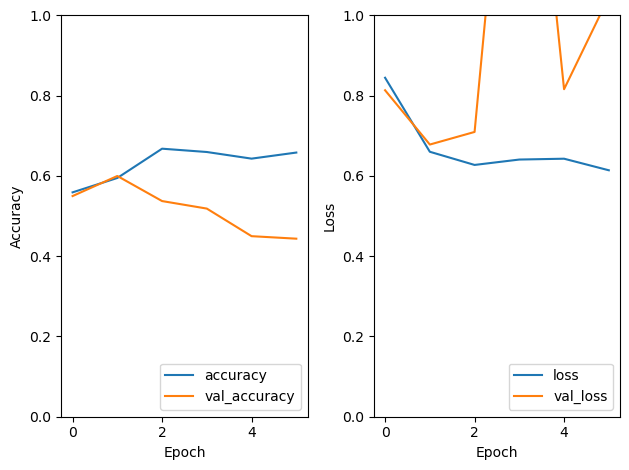

In [39]:
train_losses, train_accs, val_losses, val_accs = zip(*epochs)
fig, axs = plt.subplots(1, 2)

axs[0].plot(train_accs, label='accuracy')
axs[0].plot(val_accs, label = 'val_accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_ylim([0, 1])
axs[0].legend(loc='lower right')

axs[1].plot(train_losses, label='loss')
axs[1].plot(val_losses, label = 'val_loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_ylim([0, 1])
axs[1].legend(loc='lower right')

plt.tight_layout()